## Plan
- Load pickle file - Model Files/claim_outcome_model.pkl
- Evaluate on training and test data and generate confusion matrix, precision, recall & F1 Score
- Generate feature importance and explainability summaries
- Segment performance by city or insurance provider

In [7]:
import pandas as pd
from pycaret.classification import load_model
import json
from sklearn.metrics import confusion_matrix, classification_report
import shap
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# Load picke file from Model Files/claim_outcome_model.pkl
model_name = "../../Model Files/claim_outcome_model"
claim_model = load_model(model_name)

# Read model_table.csv and sort by visit_date
DATA_PATH = "../../Database/model_table.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["visit_date", "registration_date", "billing_date"])
df = df.sort_values("visit_date").reset_index(drop=True)

# Create derived lag_time
df["lag_time"] = (df["billing_date"] - df["visit_date"]).dt.days

# Read model feature json file
FEATURES_PATH = "../../Model Files/claim_outcome_model_feature_schema.json"
with open(FEATURES_PATH, "r") as f:
    model_features = [feat["name"] for feat in json.load(f)["features"]]

# Create a df only for those features + target
columns_to_keep = model_features + ["claim_status", "visit_date"]
df = df[columns_to_keep]

# Create x and y for the model 80:20 split no shuffling
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

Transformation Pipeline and Model Successfully Loaded


## Confusion Matrix, Recall & F1

In [9]:
# Showcase feature importance for the claim model
print("\nFeature Importance for the Claim Model:")

# PyCaret feature selection reduces the features to 9, so we fetch the names directly from the final estimator
final_estimator = claim_model.steps[-1][1]
selected_features = final_estimator.feature_names_in_

importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": final_estimator.feature_importances_
}).sort_values("Importance", ascending=False)
print(importance_df)


Feature Importance for the Claim Model:
                         Feature  Importance
5                  billed_amount    0.226157
3                   chronic_flag    0.200712
1                         gender    0.175163
6                   payment_days    0.167272
2  insurance_provider_SecureLife    0.110592
7                visit_frequency    0.100601
8                       lag_time    0.009626
4           length_of_stay_hours    0.005120
0                            age    0.004758


## Model Explanation


--- SHAP Waterfall Plot for Claim 1 ---
Profile: age=25, gender=F, city=Chennai, insurance_provider=HealthPlus, chronic_flag=1, department=ICU, visit_type=ER, length_of_stay_hours=34.36, billed_amount=5038.97, payment_days=5.0, visit_frequency=4, lag_time=-174
Prediction: Paid | Probabilities: Paid: 0.585, Pending: 0.265, Rejected: 0.150


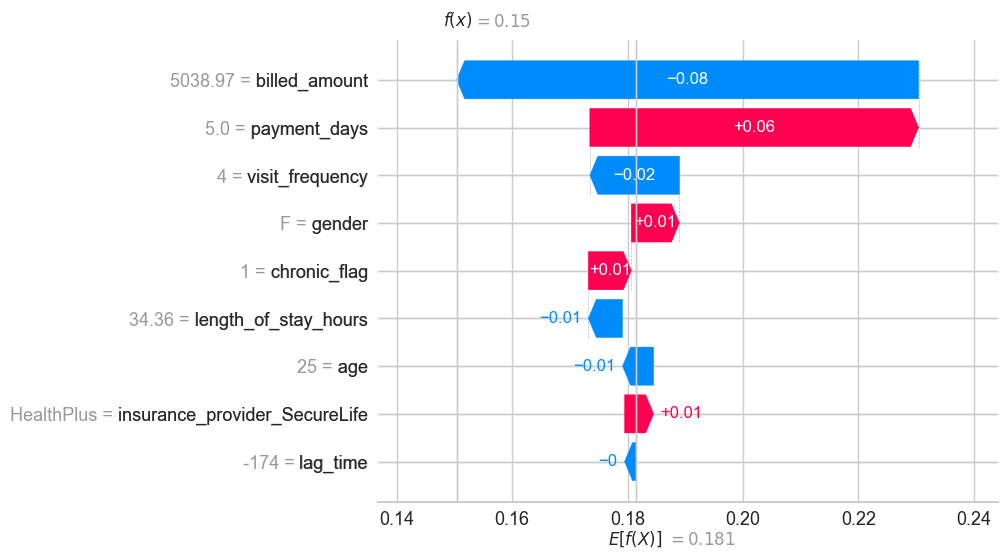


--- SHAP Waterfall Plot for Claim 2 ---
Profile: age=52, gender=M, city=Delhi, insurance_provider=CareOne, chronic_flag=1, department=General, visit_type=OPD, length_of_stay_hours=7.43, billed_amount=21173.56, payment_days=14.0, visit_frequency=3, lag_time=-289
Prediction: Paid | Probabilities: Paid: 0.529, Pending: 0.224, Rejected: 0.247


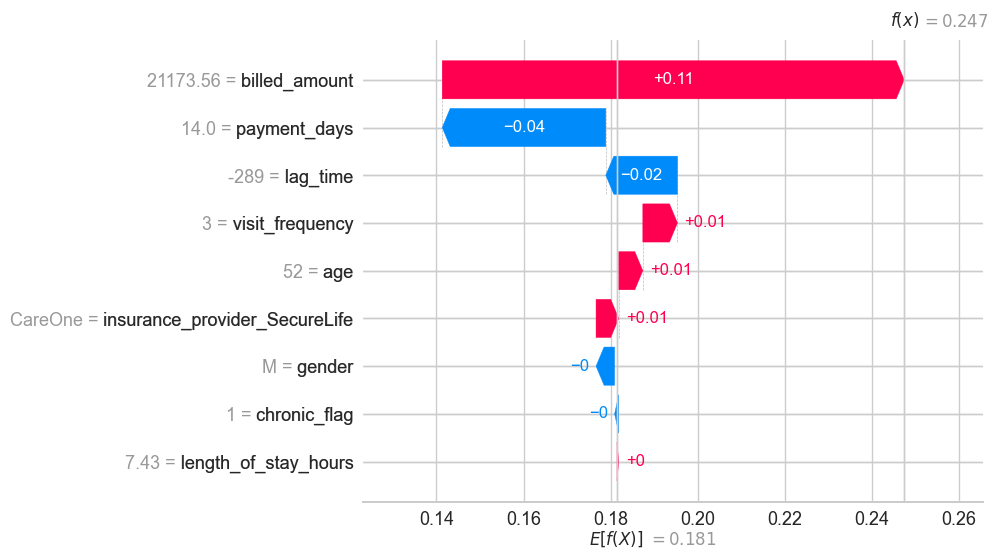


--- SHAP Waterfall Plot for Claim 3 ---
Profile: age=42, gender=F, city=Mumbai, insurance_provider=MediCareX, chronic_flag=0, department=Neurology, visit_type=ICU, length_of_stay_hours=12.74, billed_amount=21706.39, payment_days=5.0, visit_frequency=1, lag_time=-15
Prediction: Rejected | Probabilities: Paid: 0.302, Pending: 0.259, Rejected: 0.438


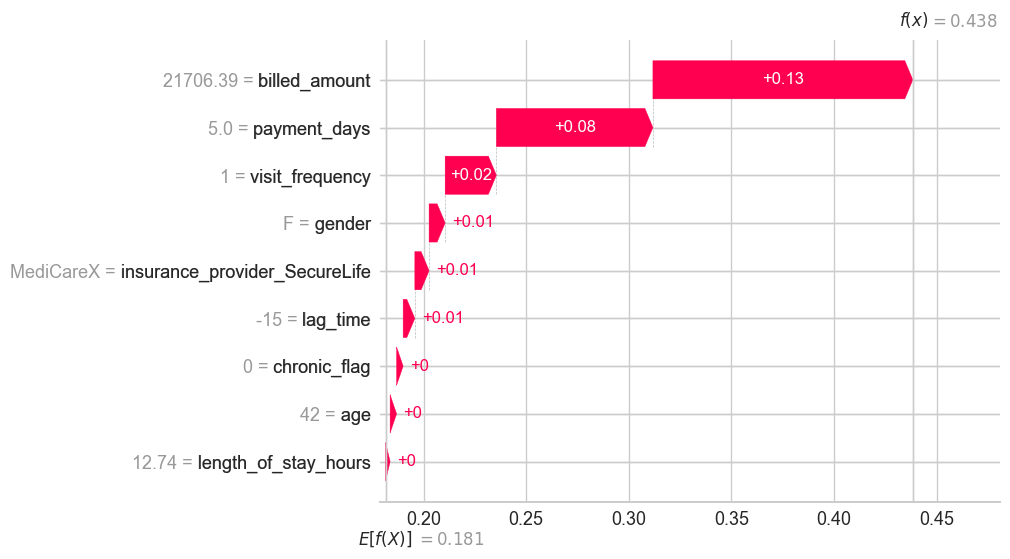


--- SHAP Waterfall Plot for Claim 4 ---
Profile: age=36, gender=M, city=Pune, insurance_provider=HealthPlus, chronic_flag=0, department=Orthopedics, visit_type=OPD, length_of_stay_hours=2.5, billed_amount=1500.0, payment_days=30.0, visit_frequency=6, lag_time=45
Prediction: Pending | Probabilities: Paid: 0.179, Pending: 0.785, Rejected: 0.036


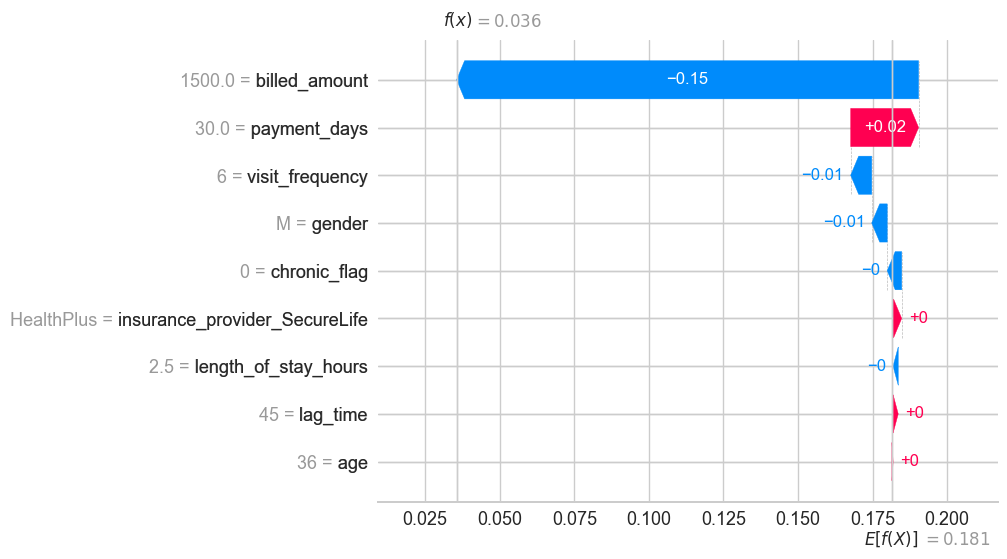


--- SHAP Waterfall Plot for Claim 5 ---
Profile: age=60, gender=M, city=Chennai, insurance_provider=CareOne, chronic_flag=1, department=Cardiology, visit_type=ICU, length_of_stay_hours=72.0, billed_amount=56000.0, payment_days=60.0, visit_frequency=12, lag_time=90
Prediction: Rejected | Probabilities: Paid: 0.316, Pending: 0.177, Rejected: 0.508


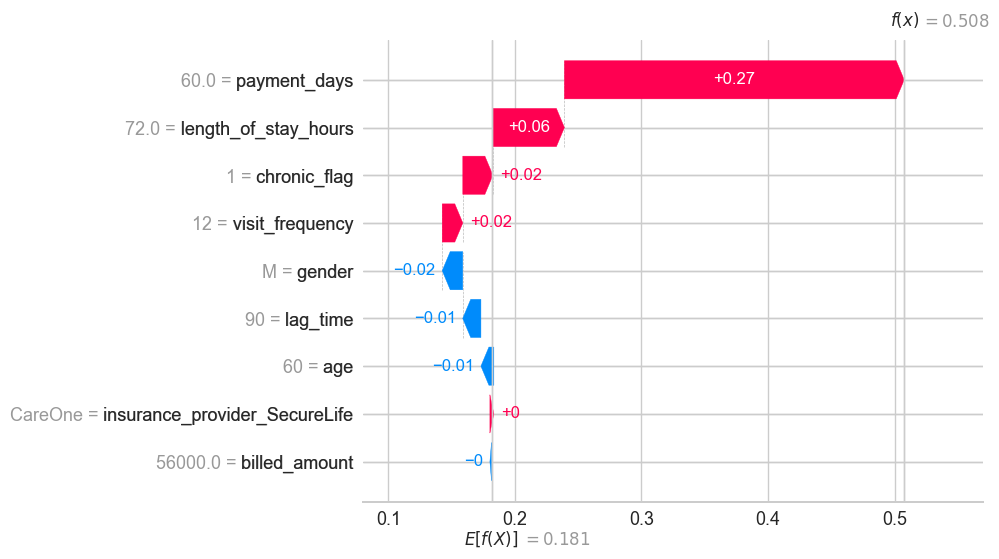

In [10]:
lean_columns = ["age", "gender", "city", "insurance_provider", "chronic_flag",
                "department", "visit_type", "length_of_stay_hours", "billed_amount",
                "payment_days", "visit_frequency", "lag_time"]

data_lean = df[lean_columns]

# Load the pipeline and extract the components
prep_pipeline = claim_model[:-1]
raw_model = claim_model.steps[-1][1]

# PyCaret encodes the target alphabetically via LabelEncoder (0=Paid, 1=Pending, 2=Rejected)
# Recover actual class labels by sorting the unique values from the dataset
class_labels = sorted(df["claim_status"].unique())
rejected_idx = class_labels.index("Rejected")

# Background dataset for SHAP
background_transformed = prep_pipeline.transform(data_lean.sample(100, random_state=42))
explainer = shap.Explainer(raw_model.predict_proba, background_transformed)

# 5 New synthetic claims arrive
new_claims_raw = pd.DataFrame([
    {"age": 25, "gender": "F", "city": "Chennai", "insurance_provider": "HealthPlus", "chronic_flag": 1, "department": "ICU", "visit_type": "ER", "length_of_stay_hours": 34.36, "billed_amount": 5038.97, "payment_days": 5.0, "visit_frequency": 4, "lag_time": -174},
    {"age": 52, "gender": "M", "city": "Delhi", "insurance_provider": "CareOne", "chronic_flag": 1, "department": "General", "visit_type": "OPD", "length_of_stay_hours": 7.43, "billed_amount": 21173.56, "payment_days": 14.0, "visit_frequency": 3, "lag_time": -289},
    {"age": 42, "gender": "F", "city": "Mumbai", "insurance_provider": "MediCareX", "chronic_flag": 0, "department": "Neurology", "visit_type": "ICU", "length_of_stay_hours": 12.74, "billed_amount": 21706.39, "payment_days": 5.0, "visit_frequency": 1, "lag_time": -15},
    {"age": 36, "gender": "M", "city": "Pune", "insurance_provider": "HealthPlus", "chronic_flag": 0, "department": "Orthopedics", "visit_type": "OPD", "length_of_stay_hours": 2.50, "billed_amount": 1500.00, "payment_days": 30.0, "visit_frequency": 6, "lag_time": 45},
    {"age": 60, "gender": "M", "city": "Chennai", "insurance_provider": "CareOne", "chronic_flag": 1, "department": "Cardiology", "visit_type": "ICU", "length_of_stay_hours": 72.00, "billed_amount": 56000.00, "payment_days": 60.0, "visit_frequency": 12, "lag_time": 90}
])

for i in range(len(new_claims_raw)):
    claim_raw = new_claims_raw.iloc[[i]]
    claim_transformed = prep_pipeline.transform(claim_raw)

    pred_class = claim_model.predict(claim_raw)[0]
    pred_proba = claim_model.predict_proba(claim_raw)[0]

    shap_values_new = explainer(claim_transformed)

    # SHAP only receives 9 features from the PyCaret pipeline due to feature selection.
    # Map raw inputs to these 9 features for readable chart labels.
    mapped_data = []
    for fname in raw_model.feature_names_in_:
        if fname in claim_raw.columns:
            mapped_data.append(claim_raw[fname].values[0])
        else:
            # Reconstruct parent category from OHE prefix (e.g. 'city_Delhi' -> 'Delhi')
            for col in ["city", "insurance_provider", "department", "visit_type"]:
                if fname.startswith(col + "_"):
                    mapped_data.append(claim_raw[col].values[0])
                    break
            else:
                mapped_data.append(claim_transformed[fname].values[0])

    shap_values_new.data = np.array([mapped_data])

    profile_parts = [f"{col}={claim_raw[col].values[0]}" for col in lean_columns]
    prob_str = ", ".join(f"{cls}: {prob:.3f}" for cls, prob in zip(class_labels, pred_proba))
    print(f"\n--- SHAP Waterfall Plot for Claim {i+1} ---")
    print(f"Profile: {', '.join(profile_parts)}")
    print(f"Prediction: {pred_class} | Probabilities: {prob_str}")

    shap.plots.waterfall(shap_values_new[0, :, rejected_idx], show=False)
    plt.show()


## Model Card

#### Model Details
- Model Name: claim_outcome_model
- Model Type: Ensemble Classifier.
- Architecture: Tree-based ensemble.
- Frameworks: PyCaret (Pipeline & Preprocessing), scikit-learn, Boosting.
- Date: May 2026

#### Intended Use
- Primary Use Case: To predict the outcome status of a medical claim (e.g., Paid, Rejected, Pending).
- Intended Users: Medical billing teams, insurance claim departments.
- Out-of-Scope Uses:
    - This model should not be used to systemically reject claims without human audit.

#### Data Processing
- Input Features:
    - age, gender, city, chronic_flag, insurance_provider, department, visit_type
    - length_of_stay_hours, billed_amount, payment_days, visit_frequency, lag_time
- Target Variable: claim_status (Multi-class).
- Training Split Strategy: Chronological split without shuffling.

#### Ethical Considerations & Limitations
  - Demographic Bias Risk: If age, gender, or city disproportionately skew rejection rates due to systemic bias, the model may explicitly leverage these.
  - Interpretability: Being a black box model, SHAP plots are essential for billing clerks.